In [ ]:
# pip install datasets

# Imports Tools

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torch.utils.data import DataLoader
from datasets import Dataset

# Load Dataset

In [ ]:
data = pd.read_csv("/content/Combined Data.csv")

# Drop Unnamed column
data = data.drop(columns=['Unnamed: 0'])
data.dropna(inplace=True)

data

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [ ]:
data = data.sample(n=6000,).reset_index(drop=True)
data

,statement,status
0,quot blip fm is undergoing maintenance quot so...,Normal
1,I feel like I shouldn't be allowed to exist be...,Bipolar
2,I really need someone to talk to. I do not kno...,Depression
3,want to go back and first,Normal
4,Being awake is so hard for me :( How do you br...,Depression
...,...,...
5995,"I have been sinking deeper into depression, wh...",Depression
5996,I have never been the person to talk abt my fe...,Depression
5997,Discombobulated And I can't figure out which o...,Bipolar
5998,Is it safe to occasionally smoke weed I’m awar...,Bipolar


# Data prerpocessing

1 Cleaning

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords (only needed once)
nltk.download('stopwords')

# Get English stopwords from NLTK
stop_words = set(stopwords.words('english'))

def clean_statement(statement):
    # Convert to lowercase
    statement = statement.lower()

    # Remove special characters (punctuation, non-alphabetic characters)
    statement = re.sub(r'[^\w\s]', '', statement)

    # Remove numbers (optional, depending on your use case)
    statement = re.sub(r'\d+', '', statement)

    # Tokenize the statement (split into words)
    words = statement.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Rejoin words into a cleaned statement
    cleaned_statement = ' '.join(words)

    return cleaned_statement

# Apply the cleaning function to the 'statement' column
data['statement'] = data['statement'].apply(clean_statement)

data

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,statement,status
0,quot blip fm undergoing maintenance quot sorry...,Normal
1,feel like shouldnt allowed exist disgusting re...,Bipolar
2,really need someone talk know feel alone right...,Depression
3,want go back first,Normal
4,awake hard break year habit sleeping hours day,Depression
...,...,...
5995,sinking deeper depression thinking valueless l...,Depression
5996,never person talk abt feelings try get help re...,Depression
5997,discombobulated cant figure one issues causing...,Bipolar
5998,safe occasionally smoke weed im aware thc caus...,Bipolar


2 balance dataset

In [ ]:
data['status'].value_counts()

,count
status,
Normal,1881
Depression,1808
Suicidal,1191
Anxiety,416
Bipolar,322
Stress,282
Personality disorder,100


In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Create an instance of RandomOverSampler
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)

# Define features (X) and target (y)
X = data.drop(columns=['status'])
y = data['status']

# Perform oversampling
X_resampled, y_resampled = ros.fit_resample(X, y)

# Combine the oversampled features and target back into a DataFrame
data = pd.concat([X_resampled, y_resampled], axis=1)

# Check the new class distribution
print(data['status'].value_counts())


status
Normal                  1881
Bipolar                 1881
Depression              1881
Suicidal                1881
Personality disorder    1881
Anxiety                 1881
Stress                  1881
Name: count, dtype: int64


 3 Encoding *Status*

In [ ]:
# Label encoding for 'status' column
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['status'])

In [ ]:
data

,statement,status,label
0,quot blip fm undergoing maintenance quot sorry...,Normal,3
1,feel like shouldnt allowed exist disgusting re...,Bipolar,1
2,really need someone talk know feel alone right...,Depression,2
3,want go back first,Normal,3
4,awake hard break year habit sleeping hours day,Depression,2
...,...,...,...
13162,female therapist says pocd pedophile ocd know ...,Suicidal,6
13163,basically feel like prisoner life feel like do...,Suicidal,6
13164,tough world know many harder social worker mas...,Suicidal,6
13165,feeling empty felt love even ex felt alone emp...,Suicidal,6


In [ ]:
mapping = data[['status', 'label']].drop_duplicates().sort_values('label')
print(mapping)

                  status  label
47               Anxiety      0
1                Bipolar      1
2             Depression      2
0                 Normal      3
33  Personality disorder      4
53                Stress      5
20              Suicidal      6


# Train Test Split

In [ ]:
# Split data into train and test
train_texts, test_texts, train_labels, test_labels = train_test_split(data['statement'], data['label'], test_size=0.2)

In [ ]:
max([len(text) for text in data['statement']])

7730

# Tokenization

In [ ]:
# Tokenization using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


train_encodings = tokenizer(list(train_texts), padding=True, truncation=True, max_length=200)
test_encodings = tokenizer(list(test_texts), padding=True, truncation=True, max_length=200)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
train_encodings.items()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Convert to Dataset format
train_dataset = Dataset.from_dict({'input_ids': train_encodings['input_ids'], 'attention_mask': train_encodings['attention_mask'], 'labels': train_labels.tolist()})
test_dataset = Dataset.from_dict({'input_ids': test_encodings['input_ids'], 'attention_mask': test_encodings['attention_mask'], 'labels': test_labels.tolist()})\

train_dataset[0]

{'input_ids': [101,
  10089,
  5082,
  8029,
  2466,
  4931,
  4364,
  4921,
  2063,
  2206,
  2451,
  2359,
  3745,
  2466,
  2672,
  3113,
  2111,
  2183,
  2714,
  3663,
  4921,
  2063,
  2196,
  2371,
  2894,
  2166,
  2514,
  2066,
  5665,
  2657,
  10047,
  3652,
  2347,
  2102,
  3733,
  4287,
  2843,
  12603,
  8056,
  3773,
  3566,
  5305,
  3492,
  2172,
  2878,
  2166,
  3652,
  11704,
  4044,
  2467,
  2165,
  2729,
  3566,
  2402,
  2287,
  2081,
  4987,
  9826,
  2130,
  2295,
  5305,
  2428,
  2190,
  2388,
  2071,
  3726,
  2412,
  2356,
  3435,
  2830,
  2843,
  3949,
  2843,
  5998,
  3566,
  6757,
  2028,
  2190,
  2086,
  7965,
  2318,
  2092,
  2190,
  2095,
  2155,
  2878,
  6854,
  2234,
  2203,
  3402,
  2979,
  2281,
  2234,
  2502,
  5213,
  3071,
  7965,
  2740,
  3471,
  3180,
  5852,
  6669,
  2986,
  2673,
  2234,
  12894,
  4921,
  2063,
  2467,
  10089,
  2349,
  10089,
  12436,
  4691,
  4600,
  2116,
  2086,
  6635,
  2337,
  16215,
  2234,
  2105,
  2

# Fine Tuning Bert

In [ ]:
BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(label_encoder.classes_))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
# # Load model
# model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_encoder.classes_))

# # Set training arguments with improvements
# training_args = TrainingArguments(
#     output_dir="./results",          # Output directory for results
#     eval_strategy="epoch",     # Evaluate once per epoch
#     save_strategy="epoch",          # Save model at the end of each epoch to match evaluation strategy
#     learning_rate=2e-5,              # Learning rate
#     per_device_train_batch_size=16,  # Batch size for training
#     per_device_eval_batch_size=16,   # Batch size for evaluation
#     num_train_epochs=5,              # Increase number of epochs
#     weight_decay=0.01,               # Strength of weight decay
#     logging_dir="./logs",            # Directory for logging
#     logging_steps=10,                # Log every 10 steps
#     lr_scheduler_type="linear",      # Use linear learning rate scheduler with warmup
#     warmup_steps=500,                # Number of warmup steps for learning rate scheduler
#     load_best_model_at_end=True,     # Load the best model at the end of training
#     metric_for_best_model="eval_loss", # Monitor eval loss to determine the best model
#     save_total_limit=3,              # Limit the number of checkpoints to save
#     gradient_accumulation_steps=2    # Simulate larger batch size if GPU memory is limited
# )
# # Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset,
# )

# # Fine-tuning the model
# trainer.train()

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
# # Load model
# model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_encoder.classes_))

# # Set training arguments with improvements
# training_args = TrainingArguments(
#     output_dir="./results",
#     eval_strategy="epoch",           # correct for transformers 4.57.1
#     save_strategy="epoch",
#     learning_rate=2e-5,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=5,
#     weight_decay=0.01,
#     logging_dir="./logs",
#     logging_steps=20,
#     lr_scheduler_type="linear",
#     warmup_steps=50,                 # reduce from 500 → 50 for small dataset
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     save_total_limit=3,

#     fp16=True,                       # REQUIRED for T4 speed
#     gradient_accumulation_steps=1,   # faster training
#     dataloader_num_workers=2,
#     disable_tqdm=False,

#     report_to="none"
# )
# # Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset,
# )

# # Fine-tuning the model
# trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,0.470300,0.412453
2,0.225500,0.249336
3,0.192500,0.277503
4,0.093100,0.306062
5,0.006100,0.324774


TrainOutput(global_step=3275, training_loss=0.2840070701282443, metrics={'train_runtime': 624.2836, 'train_samples_per_second': 83.872, 'train_steps_per_second': 5.246, 'total_flos': 5381684893200000.0, 'train_loss': 0.2840070701282443, 'epoch': 5.0})

In [ ]:
import transformers
print("transformers", transformers.__version__)

transformers 4.57.1


#  Model Evaluation


                      precision    recall  f1-score   support

             Anxiety       0.95      0.99      0.97       375
             Bipolar       1.00      0.98      0.99       366
          Depression       0.76      0.72      0.74       380
              Normal       0.90      0.93      0.91       359
Personality disorder       0.99      1.00      0.99       365
              Stress       0.96      1.00      0.98       398
            Suicidal       0.80      0.76      0.78       375

            accuracy                           0.91      2618
           macro avg       0.91      0.91      0.91      2618
        weighted avg       0.91      0.91      0.91      2618



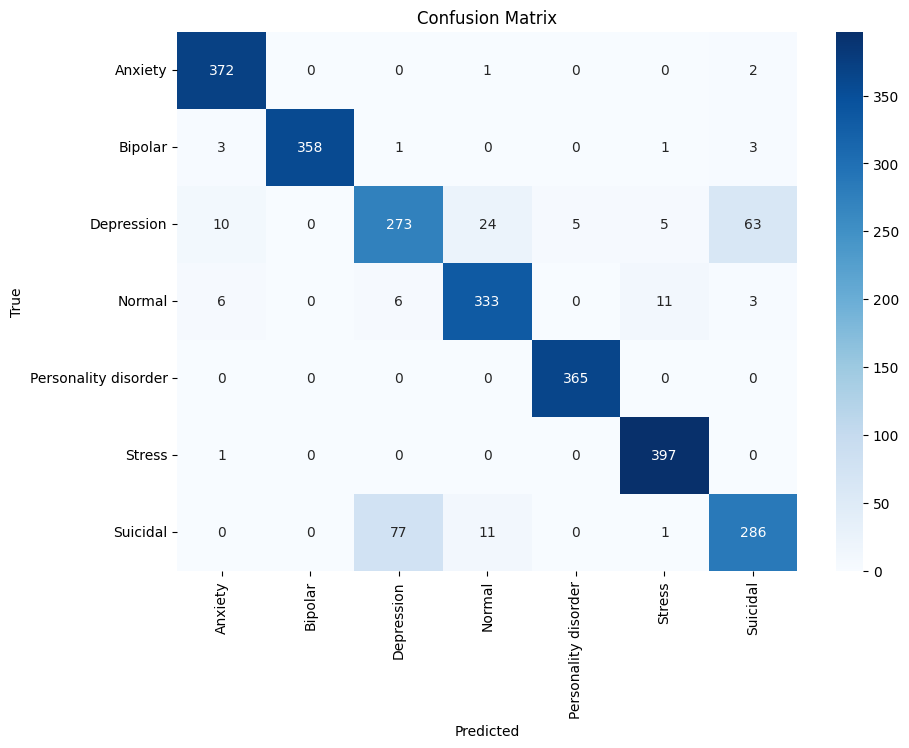

In [ ]:
# Predictions
predictions, labels, _ = trainer.predict(test_dataset)

# Convert predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Classification Report
print(classification_report(test_labels, predicted_labels, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Save and Load Model and Tokenizer

In [ ]:
# Save the trained model and tokenizer
trainer.save_model("saved_mental_status_bert")  # Save the model to the specified directory
tokenizer.save_pretrained("saved_mental_status_bert")  # Save the tokenizer


import pickle

pickle.dump(label_encoder, open('label_encoder.pkl', 'wb'))

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Load the model and tokenizer from the saved paths
model = AutoModelForSequenceClassification.from_pretrained("saved_mental_status_bert")
tokenizer = AutoTokenizer.from_pretrained("saved_mental_status_bert")

label_encoder = pickle.load(open('label_encoder.pkl', 'rb'))

# Detection System

In [ ]:
# Detection System (Example)
def detect_anxiety(text):
    cleaned_text = clean_statement(text)
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()
    return label_encoder.inverse_transform([predicted_class])[0]

# Test detection system with a mixture of normal, anxiety, bipolar, depression, suicide, etc.
sample_texts = [
    "I feel perfectly fine today, nothing to worry about.",
    "I can't stop thinking about what will happen if things go wrong.",
    "Lately, I've been on a high, feeling like I can do anything!",
    "I'm so sad, I just can't seem to get out of bed anymore.",
    "I'm constantly thinking about how much better everyone else is doing than me.",
    "I don't think I can keep going, everything feels so hopeless.",
    "I had a really good day, spent some time with my friends.",
    "I'm overwhelmed by the idea that I might lose everything.",
    "I feel like nothing matters anymore, I just want to give up.",
    "I'm okay today, but sometimes I get really anxious for no reason."
]

# Assuming the detect_anxiety function is already defined and takes a sentence as input
for text in sample_texts:
    predicted_class = detect_anxiety(text)
    print(f"Sentence: {text}\nPredicted class: {predicted_class}\n")


Sentence: I feel perfectly fine today, nothing to worry about.
Predicted class: Anxiety

Sentence: I can't stop thinking about what will happen if things go wrong.
Predicted class: Normal

Sentence: Lately, I've been on a high, feeling like I can do anything!
Predicted class: Normal

Sentence: I'm so sad, I just can't seem to get out of bed anymore.
Predicted class: Depression

Sentence: I'm constantly thinking about how much better everyone else is doing than me.
Predicted class: Personality disorder

Sentence: I don't think I can keep going, everything feels so hopeless.
Predicted class: Depression

Sentence: I had a really good day, spent some time with my friends.
Predicted class: Normal

Sentence: I'm overwhelmed by the idea that I might lose everything.
Predicted class: Normal

Sentence: I feel like nothing matters anymore, I just want to give up.
Predicted class: Depression

Sentence: I'm okay today, but sometimes I get really anxious for no reason.
Predicted class: Anxiety



# Downlaod Model To Your PC Directly

In [ ]:
import shutil
from google.colab import files

# Step 1: Save the trained model and tokenizer
model_save_path = "saved_mental_status_bert"  # Path to save the trained model
tokenizer_save_path = "saved_mental_status_bert"  # Path to save the tokenizer

# Save the model and tokenizer
trainer.save_model(model_save_path)
tokenizer.save_pretrained(tokenizer_save_path)

# Step 2: Create a zip file containing the saved model and tokenizer using shutil
zip_file_path = "saved_mental_status_bert"  # Path for the zip file without extension

# Create a zip archive of the directories
shutil.make_archive(zip_file_path, 'zip', root_dir='saved_mental_status_bert', base_dir='')

# Step 3: Provide a download link to the zip file
files.download(f"{zip_file_path}.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
txt = "How will I complete the work today?"
pred = detect_anxiety(txt)
pred

'Normal'

In [ ]:
import torch

inputs = tokenizer("I had a very bad day today",
                    return_tensors="pt",
                    truncation=True,
                    padding=True)

with torch.no_grad():
    logits = model(**inputs).logits

pred = torch.argmax(logits, dim=1).item()
print("Predicted class:", pred)


Predicted class: 3


In [ ]:
import torch
from flask import Flask, request, jsonify
from transformers import BertTokenizer, BertForSequenceClassification
import numpy as np

MODEL_NAME = "pmkastu25/mindease-mental-health-bert"

print(f"Loading BERT model: {MODEL_NAME}...")

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

Loading BERT model: pmkastu25/mindease-mental-health-bert...


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
labels = {
    0: "Anxiety",
    1: "Bipolar",
    2: "Depression",
    3: "Normal",
    4: "Personality disorder",
    5: "Stress",
    6: "Suicidal"
}

def analyze_mood():
    try:
        data = request.get_json()
        if 'text' not in data:
            return jsonify({'error': 'No text provided'}), 400

        input_text = data['text']

        # A. TOKENIZATION
        encoded_input = tokenizer(
            input_text,
            return_tensors='pt',   # PyTorch tensor
            truncation=True,
            padding=True,
            max_length=128
        )

        # B. INFERENCE
        with torch.no_grad():
            output = model(**encoded_input)

        logits = output.logits
        probabilities = torch.softmax(logits, dim=-1).numpy()[0]

        predicted_class_id = np.argmax(probabilities)
        predicted_label = labels[predicted_class_id]
        confidence_score = float(probabilities[predicted_class_id])

        response = {
            'mood': predicted_label,
            'confidence': f"{confidence_score:.2f}",
            'all_scores': {
                labels[i]: f"{prob:.4f}" for i, prob in enumerate(probabilities)
            }
        }

        return jsonify(response)

    except Exception as e:
        return jsonify({'error': str(e)}), 500

In [ ]:
def detect_anxiety(text):
    cleaned_text = clean_statement(text)

    inputs = tokenizer(
        cleaned_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1).numpy()[0]

    # Get highest probability class
    predicted_class_id = int(np.argmax(probabilities))
    confidence_score = float(probabilities[predicted_class_id])

    # If using label_encoder
    predicted_label = label_encoder.inverse_transform([predicted_class_id])[0]

    return {
        "label": predicted_label,
        "class_id": predicted_class_id,
        "confidence": confidence_score
    }


In [ ]:
# Test detection system with a mixture of normal, anxiety, bipolar, depression, suicide, etc.
sample_texts = [
    "I feel perfectly fine today, nothing to worry about.",
    "I can't stop thinking about what will happen if things go wrong.",
    "Lately, I've been on a high, feeling like I can do anything!",
    "I'm so sad, I just can't seem to get out of bed anymore.",
    "I'm constantly thinking about how much better everyone else is doing than me.",
    "I don't think I can keep going, everything feels so hopeless.",
    "I had a really good day, spent some time with my friends.",
    "I'm overwhelmed by the idea that I might lose everything.",
    "I feel like nothing matters anymore, I just want to give up.",
    "I'm okay today, but sometimes I get really anxious for no reason."
]

# Assuming the detect_anxiety function is already defined and takes a sentence as input
for text in sample_texts:
    predicted_class = detect_anxiety(text)
    print(f"Sentence: {text}\nPredicted class: {predicted_class}\n")


Sentence: I feel perfectly fine today, nothing to worry about.
Predicted class: {'label': 'Anxiety', 'class_id': 0, 'confidence': 0.9914905428886414}

Sentence: I can't stop thinking about what will happen if things go wrong.
Predicted class: {'label': 'Normal', 'class_id': 3, 'confidence': 0.9497302174568176}

Sentence: Lately, I've been on a high, feeling like I can do anything!
Predicted class: {'label': 'Normal', 'class_id': 3, 'confidence': 0.4822820723056793}

Sentence: I'm so sad, I just can't seem to get out of bed anymore.
Predicted class: {'label': 'Depression', 'class_id': 2, 'confidence': 0.8635716438293457}

Sentence: I'm constantly thinking about how much better everyone else is doing than me.
Predicted class: {'label': 'Personality disorder', 'class_id': 4, 'confidence': 0.7085810303688049}

Sentence: I don't think I can keep going, everything feels so hopeless.
Predicted class: {'label': 'Depression', 'class_id': 2, 'confidence': 0.8488852977752686}

Sentence: I had a r